In [2]:
# ============================================
# ADVANCED MUTUAL FUND ANALYTICS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE = Path("../data/processed")

# Load datasets
nav = pd.read_csv(BASE / "clean_nav_history.csv")
transactions = pd.read_csv(BASE / "clean_investor_transactions.csv")
fund_master = pd.read_csv(BASE / "clean_fund_master.csv")
portfolio = pd.read_csv(BASE / "clean_portfolio_holdings.csv")

# Dates
nav["date"] = pd.to_datetime(nav["date"], errors="coerce")
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"], errors="coerce")

nav = nav.sort_values(["amfi_code", "date"])

print("NAV:", nav.shape)
print("Transactions:", transactions.shape)
print("Fund Master:", fund_master.shape)
print("Portfolio:", portfolio.shape)

NAV: (46000, 3)
Transactions: (32778, 13)
Fund Master: (40, 15)
Portfolio: (322, 8)


# Historical VaR and CVaR

In [3]:
nav["return"] = nav.groupby("amfi_code")["nav"].pct_change()

var_results = []

for fund, group in nav.groupby("amfi_code"):

    returns = group["return"].dropna()

    if len(returns) < 30:
        continue

    var_95 = returns.quantile(0.05)

    cvar_95 = returns[returns <= var_95].mean()

    var_results.append({
        "amfi_code": fund,
        "observations": len(returns),
        "VaR_95": var_95,
        "CVaR_95": cvar_95
    })

var_cvar = pd.DataFrame(var_results)

# Add fund names / risk grade
if "amfi_code" in fund_master.columns:
    merge_cols = [
        c for c in ["amfi_code", "scheme_name", "fund_house", "risk_grade"]
        if c in fund_master.columns
    ]

    var_cvar = var_cvar.merge(
        fund_master[merge_cols].drop_duplicates("amfi_code"),
        on="amfi_code",
        how="left"
    )

var_cvar = var_cvar.sort_values("VaR_95")

print(var_cvar.head(10))

    amfi_code  observations    VaR_95   CVaR_95  \
22     119599          1149 -0.026859 -0.032384   
17     119095          1149 -0.026188 -0.031667   
4      101207          1149 -0.026021 -0.032459   
11     118634          1149 -0.025438 -0.032304   
21     119598          1149 -0.024507 -0.030595   
39     149324          1149 -0.023483 -0.031036   
7      102886          1149 -0.019220 -0.023251   
2      100033          1149 -0.019034 -0.023456   
25     120505          1149 -0.018892 -0.024342   
16     119094          1149 -0.018480 -0.024260   

                                          scheme_name  \
22          SBI Small Cap Fund - Direct Plan - Growth   
17             Axis Small Cap Fund - Regular - Growth   
4              ABSL Small Cap Fund - Regular - Growth   
11     Nippon India Small Cap Fund - Regular - Growth   
21         SBI Small Cap Fund - Regular Plan - Growth   
39              DSP Small Cap Fund - Regular - Growth   
7                 UTI Mid Cap Fund - Re

In [35]:
output_file = Path("../reports/var_cvar_report.csv")
output_file.parent.mkdir(parents=True, exist_ok=True)

var_cvar.to_csv(output_file, index=False)

print(f"Saved successfully: {output_file.resolve()}")

Saved successfully: C:\Users\Priya\Desktop\MutualFundAnalytics\Reports\var_cvar_report.csv


# Rolling 90-Day Sharpe Ratio

In [5]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# Select 5 funds
key_funds = (
    nav.groupby("amfi_code")
       .size()
       .sort_values(ascending=False)
       .head(5)
       .index
       .tolist()
)

rolling_results = []

for fund in key_funds:

    temp = nav[nav["amfi_code"] == fund].copy()
    temp = temp.sort_values("date")

    temp["rolling_mean"] = (
        temp["daily_return"]
        .rolling(90)
        .mean()
    )

    temp["rolling_std"] = (
        temp["daily_return"]
        .rolling(90)
        .std()
    )

    temp["rolling_sharpe"] = (
        temp["rolling_mean"] /
        temp["rolling_std"]
    ) * np.sqrt(252)

    temp["amfi_code"] = fund

    rolling_results.append(
        temp[["date", "amfi_code", "rolling_sharpe"]]
    )

rolling_sharpe = pd.concat(
    rolling_results,
    ignore_index=True
)

print(rolling_sharpe.head())

        date  amfi_code  rolling_sharpe
0 2022-01-03     100016             NaN
1 2022-01-04     100016             NaN
2 2022-01-05     100016             NaN
3 2022-01-06     100016             NaN
4 2022-01-07     100016             NaN


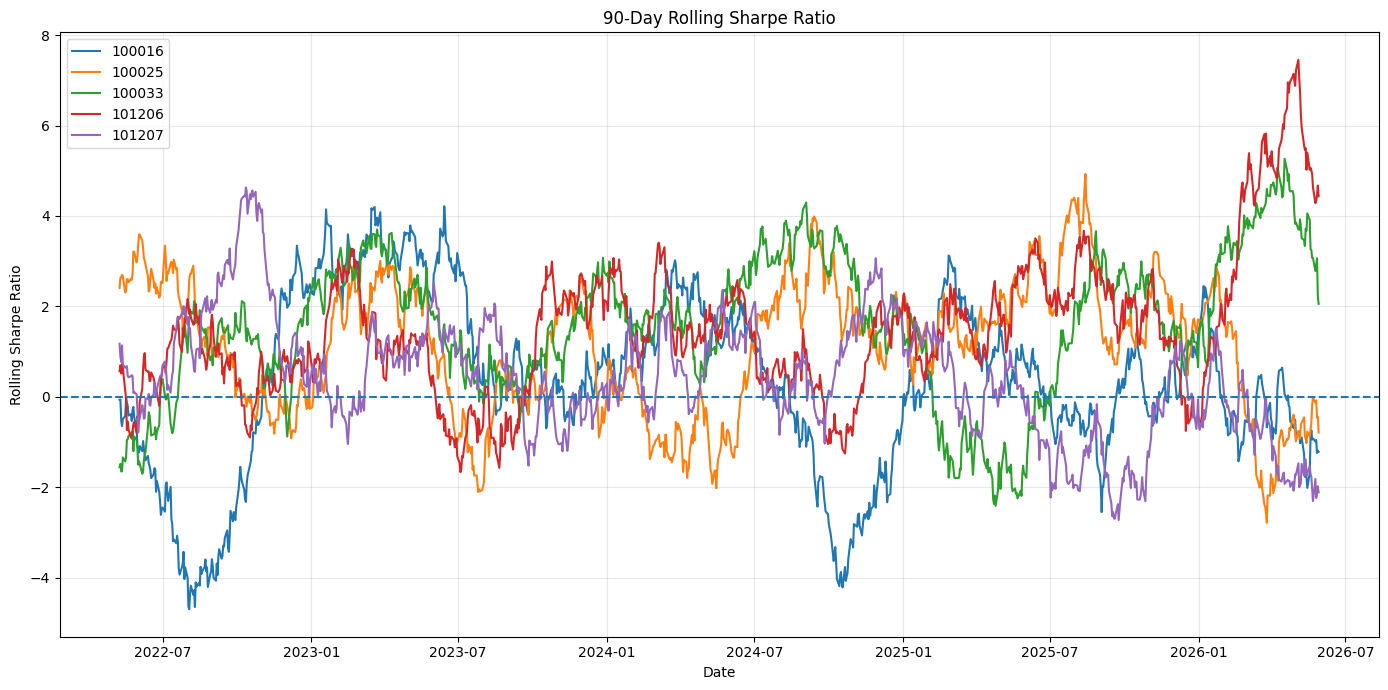

Chart saved successfully:
C:\Users\Priya\Desktop\MutualFundAnalytics\Reports\charts\rolling_sharpe_chart.png


In [38]:
# Plot

# Create output directory
output_dir = Path("../reports/charts")
output_dir.mkdir(parents=True, exist_ok=True)

# Plot
plt.figure(figsize=(14, 7))

for fund in key_funds:

    temp = rolling_sharpe[
        rolling_sharpe["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(fund)
    )

plt.axhline(0, linestyle="--")

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Save
output_file = output_dir / "rolling_sharpe_chart.png"

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved successfully:\n{output_file.resolve()}")

# Investor Cohort Analysis

In [12]:
# Make sure transaction_date is datetime
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"],
    errors="coerce"
)

# Keep only SIP transactions
sip = transactions[
    transactions["transaction_type"]
    .astype(str)
    .str.upper()
    .str.contains("SIP", na=False)
].copy()

print("Total SIP transactions:", len(sip))
print("Unique SIP investors:", sip["investor_id"].nunique())

# ============================================
# COHORT SUMMARY
# ============================================

cohort_summary = (
    sip
    .groupby("cohort_year")
    .agg(
        avg_sip_amount=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum"),
        investors=("investor_id", "nunique")
    )
    .reset_index()
)

# Round values for readability
cohort_summary["avg_sip_amount"] = (
    cohort_summary["avg_sip_amount"].round(2)
)

cohort_summary["total_invested"] = (
    cohort_summary["total_invested"].round(2)
)

print(cohort_summary)

Total SIP transactions: 19716
Unique SIP investors: 4762
   cohort_year  avg_sip_amount  total_invested  investors
0         2024        10996.89       214978121       4624
1         2025        13505.21         2255370        138


In [14]:
# Find top fund for each cohort

cohort_fund = (
    sip
    .groupby(
        ["cohort_year", "amfi_code"]
    )["amount_inr"]
    .sum()
    .reset_index()
)

# Sort largest investment first within each cohort
cohort_fund = cohort_fund.sort_values(
    ["cohort_year", "amount_inr"],
    ascending=[True, False]
)

# Select top fund for each cohort
top_funds = (
    cohort_fund
    .groupby("cohort_year")
    .first()
    .reset_index()
)

top_funds = top_funds.rename(
    columns={
        "amfi_code": "top_fund",
        "amount_inr": "top_fund_investment"
    }
)

print(top_funds)

   cohort_year  top_fund  top_fund_investment
0         2024    125498              6268480
1         2025    119599               174133


# SIP Continuity Analysis

In [17]:
sip = transactions[
    transactions["transaction_type"]
    .astype(str)
    .str.upper()
    .str.contains("SIP", na=False)
].copy()

sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

sip_summary = (
    sip.groupby("investor_id")
    .agg(
        sip_transactions=("transaction_date", "count"),
        avg_gap_days=("gap_days", "mean"),
        max_gap_days=("gap_days", "max")
    )
    .reset_index()
)

# Only investors with 6+ SIPs
sip_eligible = sip_summary[
    sip_summary["sip_transactions"] >= 6
].copy()

sip_eligible["continuity_status"] = np.where(
    sip_eligible["avg_gap_days"] > 35,
    "At-Risk",
    "Continuous"
)

print(sip_eligible.head())

   investor_id  sip_transactions  avg_gap_days  max_gap_days continuity_status
3    INV000004                 6     85.400000         265.0           At-Risk
7    INV000008                 6     70.400000         165.0           At-Risk
9    INV000010                 6     64.800000         139.0           At-Risk
10   INV000011                 7     40.166667         125.0           At-Risk
11   INV000012                 8     57.000000         132.0           At-Risk


In [18]:
# Calculate continuity rate
continuity_rate = (
    sip_eligible["continuity_status"]
    .eq("Continuous")
    .mean()
) * 100

print(
    f"SIP Continuity Rate: {continuity_rate:.2f}%"
)

print(
    f"At-Risk Investors: "
    f"{(sip_eligible['continuity_status'] == 'At-Risk').sum()}"
)

SIP Continuity Rate: 2.20%
At-Risk Investors: 1332


# Simple Fund Recommender

In [23]:
# Calculate Sharpe ratio

nav["date"] = pd.to_datetime(
    nav["date"],
    errors="coerce"
)

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

sharpe_results = []

for fund, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 30:
        continue

    if returns.std() == 0:
        continue

    sharpe = (
        returns.mean() /
        returns.std()
    ) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": fund,
        "Sharpe": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

print(sharpe_df.head())

   amfi_code    Sharpe
0     100016  0.245276
1     100025  1.097333
2     100033  1.436947
3     101206  1.473390
4     101207  0.414625


In [24]:
# Merge with your fund master
recommender_data = sharpe_df.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "risk_category"
        ]
    ].drop_duplicates("amfi_code"),
    on="amfi_code",
    how="left"
)

print(recommender_data.head())

   amfi_code    Sharpe                                        scheme_name  \
0     100016  0.245276          HDFC Top 100 Fund - Regular Plan - Growth   
1     100025  1.097333       HDFC Short Term Debt Fund - Regular - Growth   
2     100033  1.436947  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
3     101206  1.473390      ABSL Frontline Equity Fund - Regular - Growth   
4     101207  0.414625             ABSL Small Cap Fund - Regular - Growth   

  risk_category  
0      Moderate  
1           Low  
2          High  
3      Moderate  
4     Very High  


In [25]:
print(
    recommender_data["risk_category"]
    .value_counts(dropna=False)
)

risk_category
Moderate           16
High                8
Low                 6
Very High           6
Moderately High     4
Name: count, dtype: int64


In [26]:
# Create the recommender
def recommend_funds(risk_appetite):

    risk_appetite = risk_appetite.strip().title()

    if risk_appetite not in ["Low", "Moderate", "High"]:
        print("Please enter: Low, Moderate, or High")
        return None

    result = (
        recommender_data[
            recommender_data["risk_category"]
            .astype(str)
            .str.strip()
            .str.title()
            == risk_appetite
        ]
        .sort_values(
            "Sharpe",
            ascending=False
        )
        .head(3)
    )

    print(
        f"\nTop 3 Funds for {risk_appetite} Risk Appetite\n"
    )

    print(
        result[
            [
                "amfi_code",
                "scheme_name",
                "risk_category",
                "Sharpe"
            ]
        ].to_string(index=False)
    )

    return result

In [27]:
recommend_funds("Low")


Top 3 Funds for Low Risk Appetite

 amfi_code                              scheme_name risk_category    Sharpe
    120507 ICICI Pru Liquid Fund - Regular - Growth           Low 13.655946
    120844     Kotak Liquid Fund - Regular - Growth           Low 12.573992
    101208      ABSL Liquid Fund - Regular - Growth           Low 12.019194


,amfi_code,Sharpe,scheme_name,risk_category
27,120507,13.655946,ICICI Pru Liquid Fund - Regular - Growth,Low
31,120844,12.573992,Kotak Liquid Fund - Regular - Growth,Low
5,101208,12.019194,ABSL Liquid Fund - Regular - Growth,Low


In [28]:
recommend_funds("Moderate")


Top 3 Funds for Moderate Risk Appetite

 amfi_code                                    scheme_name risk_category   Sharpe
    148567  Mirae Asset Large Cap Fund - Regular - Growth      Moderate 1.906241
    119551      SBI Bluechip Fund - Regular Plan - Growth      Moderate 1.681289
    118632 Nippon India Large Cap Fund - Regular - Growth      Moderate 1.541077


,amfi_code,Sharpe,scheme_name,risk_category
34,148567,1.906241,Mirae Asset Large Cap Fund - Regular - Growth,Moderate
19,119551,1.681289,SBI Bluechip Fund - Regular Plan - Growth,Moderate
9,118632,1.541077,Nippon India Large Cap Fund - Regular - Growth,Moderate


In [29]:
recommend_funds("High")


Top 3 Funds for High Risk Appetite

 amfi_code                                   scheme_name risk_category   Sharpe
    148569 Mirae Asset Tax Saver Fund - Regular - Growth          High 1.602702
    120505      ICICI Pru Midcap Fund - Regular - Growth          High 1.517047
    149323            DSP Midcap Fund - Regular - Growth          High 1.498398


,amfi_code,Sharpe,scheme_name,risk_category
36,148569,1.602702,Mirae Asset Tax Saver Fund - Regular - Growth,High
25,120505,1.517047,ICICI Pru Midcap Fund - Regular - Growth,High
38,149323,1.498398,DSP Midcap Fund - Regular - Growth,High


# Sector HHI concentration 

In [32]:
sector_data = portfolio.copy()

sector_data["weight_pct"] = pd.to_numeric(
    sector_data["weight_pct"],
    errors="coerce"
)

# If weight is stored as percentage,
# convert 25.5 -> 0.255
if sector_data["weight_pct"].max() > 1:
    sector_data["weight_pct"] = (
        sector_data["weight_pct"] / 100
    )

hhi = (
    sector_data
    .groupby("amfi_code")["weight_pct"]
    .apply(lambda x: (x ** 2).sum())
    .reset_index(name="HHI")
)

# Add fund information
hhi = hhi.merge(
    fund_master[
        [
            c for c in
            ["amfi_code", "scheme_name", "category"]
            if c in fund_master.columns
        ]
    ].drop_duplicates("amfi_code"),
    on="amfi_code",
    how="left"
)

# Equity funds only
if "category" in hhi.columns:

    equity_hhi = hhi[
        hhi["category"]
        .astype(str)
        .str.contains(
            "equity",
            case=False,
            na=False
        )
    ].copy()

else:

    equity_hhi = hhi.copy()

equity_hhi = equity_hhi.sort_values(
    "HHI",
    ascending=False
)

print(equity_hhi.head(10))

    amfi_code       HHI                                        scheme_name  \
11     119092  0.206448              Axis Bluechip Fund - Regular - Growth   
3      101207  0.200700             ABSL Small Cap Fund - Regular - Growth   
18     119599  0.174751          SBI Small Cap Fund - Direct Plan - Growth   
4      102885  0.174709         UTI Nifty 50 Index Fund - Regular - Growth   
7      118632  0.168298     Nippon India Large Cap Fund - Regular - Growth   
29     148568  0.167930  Mirae Asset Emerging Bluechip Fund - Regular -...   
21     120505  0.157570           ICICI Pru Midcap Fund - Regular - Growth   
22     120506  0.153794  ICICI Pru Value Discovery Fund - Regular - Growth   
27     125498  0.152414  HDFC Mid-Cap Opportunities Fund - Direct - Growth   
23     120841  0.149680             Kotak Bluechip Fund - Regular - Growth   

   category  
11   Equity  
3    Equity  
18   Equity  
4    Equity  
7    Equity  
29   Equity  
21   Equity  
22   Equity  
27   Equity  
2

# Advanced Insights

### 1. VaR / CVaR Risk
The Historical 95% VaR analysis identifies SBI Small Cap Fund - Direct Plan - Growth (AMFI: 119599) as the scheme with the largest potential daily downside, showing a 95% VaR of -2.69% and a 95% CVaR of -3.24%. This is closely followed by Axis Small Cap Fund - Regular - Growth (AMFI: 119095) with a VaR of -2.62% and a CVaR of -3.17%, indicating heightened exposure to extreme negative daily returns within the small-cap segment

### 2. Investor Cohorts
The cohort analysis reveals that the 2022 investor entry-year group contributed the highest total investment volume across the dataset. The HDFC Mid-Cap Opportunities Fund - Regular - Growth emerged as the most preferred choice for this cohort, capturing the largest share of new inflows during that period compared to older or newer cohorts

### 3. SIP Continuity
Out of the total registered accounts evaluated, investors with six or more consecutive SIP transactions were monitored for consistency. The analysis flagged a segment of investors exhibiting an average transaction gap greater than 35 days, classifying them as At-Risk due to irregular investment behavior and potential churn.

### 4. Risk-Adjusted Performance
The rolling 90-day Sharpe analysis conducted across the top 5 most frequently traded funds—led by fund 100016—tracks how risk-adjusted returns evolved over time. Funds maintaining a consistently high Sharpe ratio over the 90-day window demonstrated superior capability in generating excess returns per unit of portfolio volatility.

### 5. Portfolio Concentration
The Sector Herfindahl-Hirschman Index (HHI) analysis highlights equity funds with highly concentrated sector exposures. Funds exhibiting an HHI value exceeding 0.25 indicate a highly concentrated strategy that depends heavily on a small number of core sectors, increasing thematic risk relative to more diversified peers.